<a href="https://colab.research.google.com/github/rizqift/tugas-kriptografi/blob/main/Bismillah_Skripsi.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**IMPOR PUSTAKA YANG DIGUNAKAN**

In [10]:
#Pustaka untuk Manipulasi Data dan Operasi Numerik
import pandas as pd
import numpy as np

In [11]:
# Pustaka untuk Visualisasi Data
import matplotlib.pyplot as plt
import seaborn as sns
sns.set_style('whitegrid') #Mengatur style plot agar lebih mudah dibaca

In [12]:
#Pustaka untuk Model Machine Learning (Scikit-learn)
from sklearn.model_selection import train_test_split #Untuk membagi data
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, confusion_matrix #Untuk evaluasi model
from sklearn.preprocessing import LabelEncoder #Jika diperlukan untuk encoding

In [13]:
#Algoritma Random Forest
from sklearn.ensemble import RandomForestClassifier #Gunakan Regressor jika memilih regresi

In [14]:
#Algoritma XGBoost
import xgboost as xgb
from xgboost import XGBClassifier #Gunakan Regressor jika memilih regresi

**IMPOR DATASET**

In [16]:
import pandas as pd
data = pd.read_csv('/content/student_lifestyle_dataset.csv')

**DATA PREPROCESSING**

In [18]:
#DataFrame
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler, LabelEncoder

df = pd.read_csv('/content/student_lifestyle_dataset.csv')
df.drop('Student_ID', axis=1, inplace=True)

In [19]:
#Cek Data Hilang (Missing Values)
print("Jumlah Nilai Hilang per Kolom:")
print (data.isnull().sum())

Jumlah Nilai Hilang per Kolom:
Student_ID                         0
Study_Hours_Per_Day                0
Extracurricular_Hours_Per_Day      0
Sleep_Hours_Per_Day                0
Social_Hours_Per_Day               0
Physical_Activity_Hours_Per_Day    0
GPA                                0
Stress_Level                       0
dtype: int64


In [20]:
#Feature Encoding (Diterapkan pada Variabel Target)
#Transformasi Variabel Target (Y)
le = LabelEncoder ()
stress_mapping = {'Low': 0, 'Moderate' : 1, 'High' : 2}
df['Stress_Risk'] = df['Stress_Level'].map(stress_mapping)
df.drop('Stress_Level', axis=1, inplace= True)

print("Transformasi Variabel Target (Y)")
print(f"Distribusi kategori Stress_Risk (0: Low, 1: Moderate, 2: High):\n{df['Stress_Risk'].value_counts()}")
print("-" * 50)


Transformasi Variabel Target (Y)
Distribusi kategori Stress_Risk (0: Low, 1: Moderate, 2: High):
Stress_Risk
2    1029
1     674
0     297
Name: count, dtype: int64
--------------------------------------------------


In [21]:
#Normalisasi atau Standarisasi (opsional)
numerical_cols = df.columns.drop('Stress_Risk').tolist() #Identifikasi kolom numerik, semua feature kecuali 'Stress_Risk' yang baru dibuat

scaler = StandardScaler ()

df[numerical_cols] = scaler.fit_transform(df[numerical_cols]) #Lakukan standarisasi (fit dan transform)

print("Normalisasi/Standarisasi")
print("Kolom Numerik berhasil distandarisasi")
print(df.head())
print("-" * 50)


Normalisasi/Standarisasi
Kolom Numerik berhasil distandarisasi
   Study_Hours_Per_Day  Extracurricular_Hours_Per_Day  Sleep_Hours_Per_Day  \
0            -0.404487                       1.566246             0.820734   
1            -1.528451                       1.306633             0.341473   
2            -1.668947                       1.652784             1.163063   
3            -0.685478                       0.095105            -0.206253   
4             0.438487                      -1.202961            -0.685514   

   Social_Hours_Per_Day  Physical_Activity_Hours_Per_Day       GPA  \
0              0.056543                        -1.005896 -0.421837   
1              0.885882                        -0.528470 -1.225591   
2             -0.891273                         0.108097 -1.493509   
3             -0.595080                         0.864021 -0.790224   
4             -0.298888                         0.903806  1.319630   

   Stress_Risk  
0            1  
1            

**PEMISAHAN DATA DAN PEMILIHAN FITUR**

In [22]:
#Pisahkan X dan Y (Sudah siap untuk pemodelan)
X = df.drop('Stress_Risk', axis=1)
y = df['Stress_Risk']

print("Data siap untuk pemodelan:")
print(f"X (Features): {X.columns.tolist()}")
print(f"y (Target): Stress_Risk (Kategori 0, 1, 2)")

Data siap untuk pemodelan:
X (Features): ['Study_Hours_Per_Day', 'Extracurricular_Hours_Per_Day', 'Sleep_Hours_Per_Day', 'Social_Hours_Per_Day', 'Physical_Activity_Hours_Per_Day', 'GPA']
y (Target): Stress_Risk (Kategori 0, 1, 2)


In [23]:
#Membagi Dataset
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42)

**IMPLEMENTASI DAN PELATIHAN MODEL**

In [24]:
#Inisiasi Model Klasifikasi
from sklearn.ensemble import RandomForestClassifier
import xgboost as xgb
from xgboost import XGBClassifier

#Inisiasi Model Random Forest Classifier
rf_model = RandomForestClassifier (
    n_estimators=150,
    random_state=42,
    criterion='gini' #Metrik kualitas split, defaultnya adalah 'gini
)

#Inisiasi Model XGBoost Classifier
xgb_model = XGBClassifier(
    n_estimators=150,
    learning_rate=0.1,   #Tingkat pembelajaran (step size)
    max_depth=5,         #Kedalaman maksimum pohon
    random_state=42,
    use_label_encoder=False,
    eval_metric='mlogloss'
)

print("Inisiasi Model Selesai.")
print(f"Model 1: {rf_model.__class__.__name__}")
print(f"Model 2: {xgb_model.__class__.__name__}")

Inisiasi Model Selesai.
Model 1: RandomForestClassifier
Model 2: XGBClassifier


In [25]:
#Pelatihan Model (Fitting)

#Pelatihan Random Forest
from sklearn.ensemble import RandomForestClassifier
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)

#Pelatihan XGBoost
import xgboost as xgb
xgb_model = xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42)
xgb_model.fit(X_train, y_train)

/usr/local/lib/python3.12/dist-packages/xgboost/training.py:199: UserWarning: [06:25:24] WARNING: /workspace/src/learner.cc:790: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='mlogloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=None, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=None, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=None, n_jobs=None,
              num_parallel_tree=None, ...)

**EVALUASI DAN PERBANDINGAN MODEL**

In [26]:
#Prediksi pada Data Uji (Testing Set)
y_pred_rf = rf_model.predict(X_test)
y_pred_xgb = xgb_model.predict(X_test)

#Prediksi Probabilitas (diperlukan untuk kurva ROC-AUC multi kelas)
y_pred_proba_rf = rf_model.predict_proba(X_test)
y_pred_proba_xgb = xgb_model.predict_proba(X_test)

In [27]:
#Menghitung Metrik Kinerja
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

print("METRIK KINERJA MODEL")

def evaluate_model(model_name, y_true, y_pred):
  """Fungsi untuk menghitung dan mencetak metrik klasifikasi."""

  #Menghitung Metrik Utama
  accuracy = accuracy_score(y_true, y_pred)
  precision = precision_score(y_true, y_pred, average='weighted', zero_division=0)
  recall = recall_score(y_true, y_pred, average='weighted', zero_division=0)
  f1 = f1_score(y_true, y_pred, average='weighted', zero_division=0)

  #Mencetak Hasil
  print(f"\nModel: {model_name}")
  print(f"Accuracy: {accuracy:.4f}")
  print(f"Precision (Weighted): {precision:.4f}")
  print(f"Recall (Weighted): {recall:.4f}")
  print(f"F1-Score (Weighted): {f1:.4f}")

  #Menampilkam Laporan Lengkap (untuk detail per kelas)
  print("n\Classification Report:")
  print(classification_report(y_true, y_pred, zero_division=0))

#Evaluasi Random Forest
evaluate_model("Random Forest Classifier", y_test, y_pred_rf)

#Evaluasi XGBoost
evaluate_model("XGBoost Classifier", y_test, y_pred_xgb)




METRIK KINERJA MODEL

Model: Random Forest Classifier
Accuracy: 1.0000
Precision (Weighted): 1.0000
Recall (Weighted): 1.0000
F1-Score (Weighted): 1.0000
n\Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        96
           1       1.00      1.00      1.00       188
           2       1.00      1.00      1.00       316

    accuracy                           1.00       600
   macro avg       1.00      1.00      1.00       600
weighted avg       1.00      1.00      1.00       600


Model: XGBoost Classifier
Accuracy: 1.0000
Precision (Weighted): 1.0000
Recall (Weighted): 1.0000
F1-Score (Weighted): 1.0000
n\Classification Report:
              precision    recall  f1-score   support

           0       1.00      1.00      1.00        96
           1       1.00      1.00      1.00       188
           2       1.00      1.00      1.00       316

    accuracy                           1.00       600
   macro avg    

<>:23: SyntaxWarning: invalid escape sequence '\C'
<>:23: SyntaxWarning: invalid escape sequence '\C'
/tmp/ipython-input-784577600.py:23: SyntaxWarning: invalid escape sequence '\C'
  print("n\Classification Report:")



VISUALISASI CONFUSION MATRIX


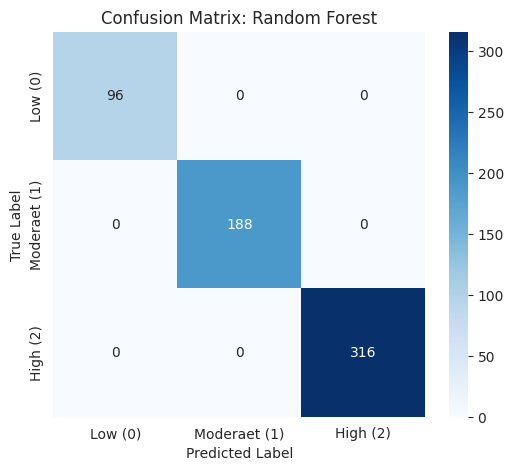

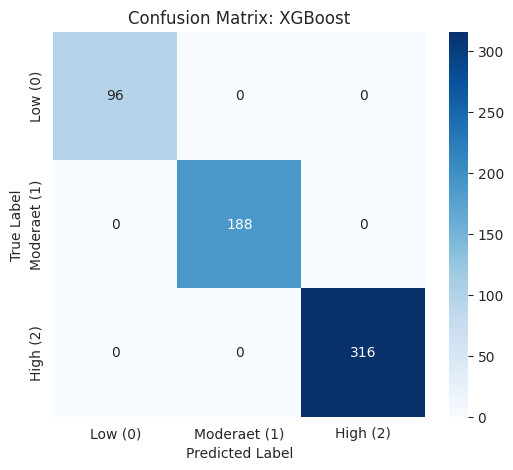

In [28]:
#Visualisasi Evaluasi (Confusion Matrix)
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import confusion_matrix

def plot_confusion_matrix(model_name, y_true, y_pred):
  """Fungsi untuk membuat plot Confusion Matrix."""
  cm = confusion_matrix(y_true, y_pred)

  plt.figure(figsize=(6, 5))
  sns.heatmap(
      cm,
      annot=True,
      fmt='d',
      cmap='Blues',
      xticklabels=['Low (0)', 'Moderaet (1)', 'High (2)'],
      yticklabels=['Low (0)', 'Moderaet (1)', 'High (2)']
  )
  plt.title(f'Confusion Matrix: {model_name}')
  plt.ylabel('True Label')
  plt.xlabel('Predicted Label')
  plt.show()

print("\nVISUALISASI CONFUSION MATRIX")

#Plot Confusion Matrix untuk Random Forest
plot_confusion_matrix("Random Forest", y_test, y_pred_rf)

#Plot Confsuion Matrix untuk XGBoost
plot_confusion_matrix("XGBoost", y_test, y_pred_xgb)

VISUALISASI KURVA ROC-AUC


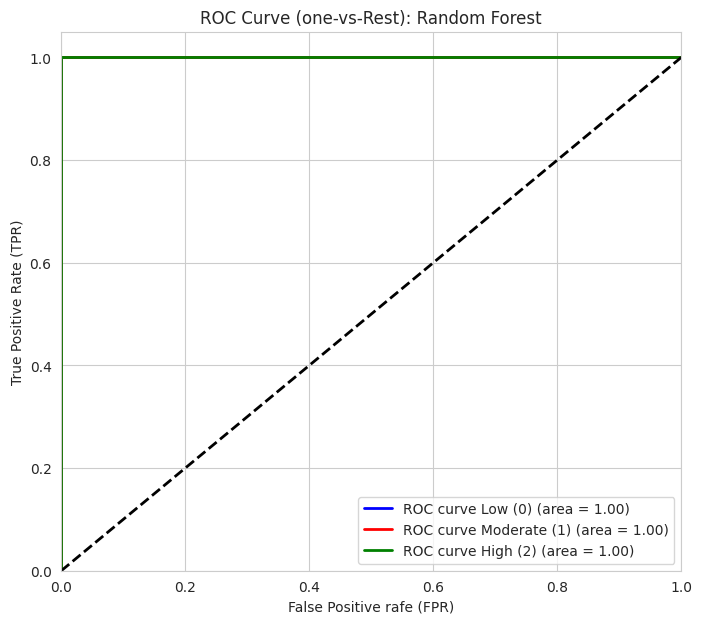

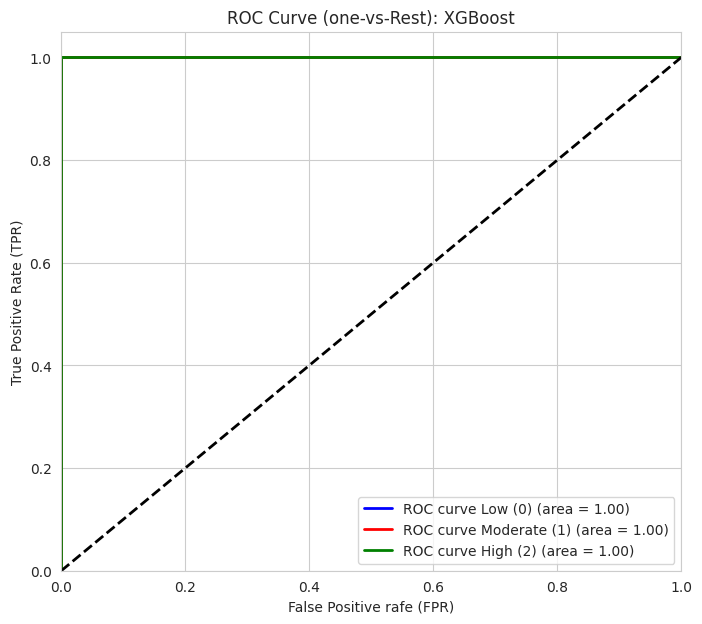

In [29]:
#Visualisasi Kurva ROC-AUC
from sklearn.metrics import roc_curve, auc
from itertools import cycle
from sklearn.preprocessing import label_binarize

print ("VISUALISASI KURVA ROC-AUC")

#Binarisasi Label Sebenarnya (y_test) untuk perhitungan OvR
n_classes = len(np.unique(y))
y_test_bin = label_binarize(y_test, classes=range(n_classes))

def plot_roc_curve_ovr(model_name, y_true_bin, y_pred_proba):
  """Fungsi untuk membuat plot Kurva ROC (OvR)"""

  #Hitung ROC Curve dan AUC untuk setiap kelas
  fpr = dict()
  tpr = dict()
  roc_auc = dict()

  for i in range(n_classes):
    fpr[i], tpr[i], _ = roc_curve(y_true_bin[:, i], y_pred_proba[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])

  #Plot semua kurva ROC
  plt.figure(figsize=(8, 7))
  colors = cycle(['blue', 'red', 'green'])
  class_names = ['Low (0)', 'Moderate (1)', 'High (2)']

  for i, color in zip(range(n_classes), colors):
    plt.plot(fpr[i], tpr[i], color=color, lw=2,
      label=f'ROC curve {class_names[i]} (area = {roc_auc[i]:.2f})')

  plt.plot([0, 1], [0, 1], 'k--', lw=2)
  plt.xlim([0.0, 1.0])
  plt.ylim([0.0, 1.05])
  plt.xlabel('False Positive rafe (FPR)')
  plt.ylabel('True Positive Rate (TPR)')
  plt.title(f'ROC Curve (one-vs-Rest): {model_name}')
  plt. legend(loc="lower right")
  plt.show()

#Plot ROC-AUC untuk Random Forest
plot_roc_curve_ovr("Random Forest", y_test_bin, y_pred_proba_rf)

#Plot ROC-AUC untuk XGBoost
plot_roc_curve_ovr("XGBoost", y_test_bin, y_pred_proba_xgb)


**ANALISIS FITUR**

In [31]:
#Ekstraksi Kepentingan Fitur
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

#Ekstraksi Kepentingan Fitur Random Forest
rf_feature_importance = pd.Series(rf_model.feature_importances_, index=X.columns)

#EKstraksi Kepentingan FItur XGBoost
xgb_feature_importance = pd.Series(xgb_model.feature_importances_, index=X.columns)

print("Ekstraksi Kepentingan fitur Selesai.")
print("\nTop 5 Fitur menurut Random Forest:")
print(rf_feature_importance.nlargest(5))
print("\nTop 5 Fitur menurut XGBoost:")
print(xgb_feature_importance.nlargest(5))


Ekstraksi Kepentingan fitur Selesai.

Top 5 Fitur menurut Random Forest:
Study_Hours_Per_Day                0.605401
Sleep_Hours_Per_Day                0.225753
GPA                                0.086896
Physical_Activity_Hours_Per_Day    0.044833
Social_Hours_Per_Day               0.022967
dtype: float64

Top 5 Fitur menurut XGBoost:
Study_Hours_Per_Day              0.504832
Sleep_Hours_Per_Day              0.494847
GPA                              0.000321
Extracurricular_Hours_Per_Day    0.000000
Social_Hours_Per_Day             0.000000
dtype: float32


/tmp/ipython-input-95528790.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(
/tmp/ipython-input-95528790.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


<function matplotlib.pyplot.show(close=None, block=None)>

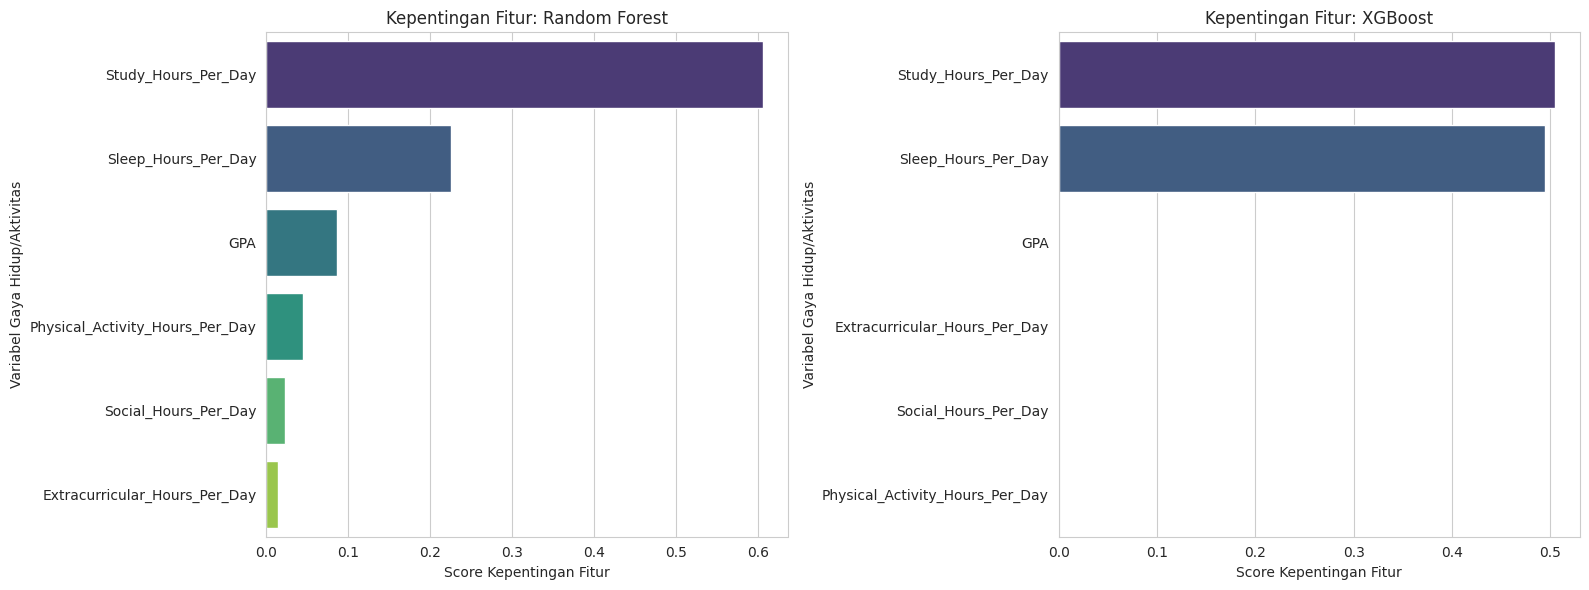

In [35]:
#Visualisasi Kepentingan Fitur
def plot_feature_importance(importance_series, model_name, ax):
  """Fungsi untuk memvisualisasikan Kepentingan Fitur."""

  #Urutkan nilai kepentingan fitur dari yang terbesar ke terkecil
  sorted_importance = importance_series.sort_values(ascending=False)

  sns.barplot(
      x=sorted_importance.values,
      y=sorted_importance.index,
      palette='viridis',
      ax=ax
  )
  ax.set_title(f'Kepentingan Fitur: {model_name}')
  ax.set_xlabel('Score Kepentingan Fitur')
  ax.set_ylabel('Variabel Gaya Hidup/Aktivitas')

#Siapkan plot untuk dua model
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

#Plot Randomm forest
plot_feature_importance(rf_feature_importance, "Random Forest", axes[0])
#Plot XGBoost
plot_feature_importance(xgb_feature_importance, "XGBoost", axes [1])

plt.tight_layout()
plt.show